In [49]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

In [50]:
load_dotenv(override=True)

True

In [51]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [52]:
graph_builder = StateGraph(State)

In [53]:
llm_client = ChatOpenAI(model="gpt-4.1-nano")
def llm_call_node(old_state: State) -> State:
    response = llm_client.invoke(old_state.messages)
    new_state = State(messages=[response])
    print(f"new_state : {new_state}")
    return new_state

graph_builder.add_node("chatbot_node", llm_call_node)

In [54]:
graph_builder.add_edge(START, "chatbot_node")
graph_builder.add_edge("chatbot_node", END)

In [55]:
graph = graph_builder.compile()

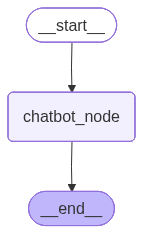

In [56]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [57]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(initial_state)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


new_state : messages=[AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_3882fd971e', 'id': 'chatcmpl-DvGOpvUE5uN2YTtH9LUaiX3YBrttM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f07ab-7c18-7d11-943e-eb178d571d1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]
messages=[{'role': 'user', 'content': 'hi'}]


/Users/nikhilsharma/Downloads/Internal Drive/Personal Projects/AI-Projects/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
